In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
df = pd.read_csv('/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv')
df.head()

/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
df.nunique()

Index                187531
Title                 32446
Description           65634
Amount(in rupees)      1561
Price (in rupees)     10958
location                 81
Carpet Area            2758
Status                    1
Floor                   947
Transaction               4
Furnishing                3
facing                    8
overlooking              19
Society               10376
Bathroom                 11
Balcony                  11
Car Parking             229
Ownership                 4
Super Area             2976
Dimensions                0
Plot Area                 0
dtype: int64

**Title**

In [3]:
# 先把 Title 轉成乾淨的文字格式
title_text = df["Title"].fillna("").astype(str).str.strip()

# 1. 擷取 BHK 前面的數字
df["Title_BHK"] = title_text.str.extract(r"(?i)\b(\d+)\s*BHK\b")[0]
df["Title_BHK"] = pd.to_numeric(df["Title_BHK"], errors="coerce")

# 2. 擷取 for sale in 後面，或 for sale 後面的文字
df["Title_place"] = title_text.str.extract(
    r"(?i)\bfor\s+sale(?:\s+in)?\s+(.+)$"
)[0]

# 清理 Title_place 前後多餘空白
df["Title_place"] = df["Title_place"].astype("string").str.strip()

# 看結果
df[["Title", "Title_BHK", "Title_place"]].head(20)

,Title,Title_BHK,Title_place
0,1 BHK Ready to Occupy Flat for sale in Srushti...,1.0,Srushti Siddhi Mangal Murti Complex Bhiwandi
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,2.0,Dosti Vihar Pokhran Road
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,2.0,Sunrise by Kalpataru Kolshet Road
3,1 BHK Ready to Occupy Flat for sale Kasheli,1.0,Kasheli
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,2.0,TenX Habitat Raymond Realty Pokhran Road
5,1 BHK Ready to Occupy Flat for sale in Virat A...,1.0,Virat Aangan Titwala
6,1 BHK Ready to Occupy Flat for sale Mumbra,1.0,Mumbra
7,1 BHK Ready to Occupy Flat for sale Kalwa,1.0,Kalwa
8,1 BHK Ready to Occupy Flat for sale Kalwa,1.0,Kalwa
9,3 BHK Ready to Occupy Flat for sale in Pride P...,3.0,Pride Palms Kolshet


In [4]:
df[["Title_BHK", "Title_place"]].isnull().sum()

Title_BHK      921
Title_place      0
dtype: int64

In [5]:
df.loc[df["Title_BHK"].isnull(), "Title"].head(50)

115                Studio Apartment for sale Dombivli East
149                 Studio Apartment for sale Vartak Nagar
150       Studio Apartment for sale in Lok Nagari Phase...
278                     Studio Apartment for sale Asangaon
293                         Apartment for sale Kisan Nagar
308                Studio Apartment for sale Badlapur West
332       Studio Apartment for sale in Hiranandani Soli...
423                   Studio Apartment for sale Thane West
616        Studio Apartment for sale Badlapur (East) Thane
635                   Studio Apartment for sale Thane West
649                       Studio Apartment for sale Kalyan
651               Studio Apartment for sale Nandivali Gaon
726                     Studio Apartment for sale Dombivli
757                    Studio Apartment for sale Ambernath
859                  Studio Apartment for sale Kalyan East
868       Studio Apartment for sale in Mhatre Apt Nandivli
872                   Studio Apartment for sale Talav Pa

In [6]:
title_text = df["Title"].fillna("").astype(str).str.strip()

# 先抓一般的 1 BHK、2 BHK、3 BHK...
df["Title_BHK"] = title_text.str.extract(r"(?i)\b(\d+)\s*BHK\b")[0]
df["Title_BHK"] = pd.to_numeric(df["Title_BHK"], errors="coerce")

# 如果 Title 裡面有 Studio Apartment，就把 Title_BHK 設成 0
studio_mask = title_text.str.contains(r"(?i)\bstudio\s+apartment\b", na=False)
df.loc[studio_mask, "Title_BHK"] = 0

# 擷取 for sale in 後面，或 for sale 後面的文字
df["Title_place"] = title_text.str.extract(
    r"(?i)\bfor\s+sale(?:\s+in)?\s+(.+)$"
)[0]

df["Title_place"] = df["Title_place"].astype("string").str.strip()

In [7]:
df["Title_BHK"].isnull().sum()
df.loc[studio_mask, ["Title", "Title_BHK", "Title_place"]].head(20)

,Title,Title_BHK,Title_place
115,Studio Apartment for sale Dombivli East,0.0,Dombivli East
149,Studio Apartment for sale Vartak Nagar,0.0,Vartak Nagar
150,Studio Apartment for sale in Lok Nagari Phase...,0.0,Lok Nagari Phase III Ambernath East
278,Studio Apartment for sale Asangaon,0.0,Asangaon
308,Studio Apartment for sale Badlapur West,0.0,Badlapur West
332,Studio Apartment for sale in Hiranandani Soli...,0.0,Hiranandani Solitaire Hiranandani Estate
423,Studio Apartment for sale Thane West,0.0,Thane West
616,Studio Apartment for sale Badlapur (East) Thane,0.0,Badlapur (East) Thane
635,Studio Apartment for sale Thane West,0.0,Thane West
649,Studio Apartment for sale Kalyan,0.0,Kalyan


In [8]:
df.loc[df["Title_BHK"].isnull(), ["Title", "Title_place"]].head(50)

,Title,Title_place
293,Apartment for sale Kisan Nagar,Kisan Nagar
2580,Apartment for sale in Shivam Parivar Sidhivin...,Shivam Parivar Sidhivinayak C H S Ghatkopar West
5277,"Apartment for sale South Bopal, Bopal","South Bopal, Bopal"
16424,Apartment for sale S R Layout Murgesh Pallya,S R Layout Murgesh Pallya
16601,Apartment for sale S R Layout Murgesh Pallya,S R Layout Murgesh Pallya
16637,Apartment for sale S R Layout Murgesh Pallya,S R Layout Murgesh Pallya
17110,Apartment for sale Muneshwara Nagar Railway L...,Muneshwara Nagar Railway Layout
17445,Apartment for sale in Krishna Residency Horamavu,Krishna Residency Horamavu
39483,Apartment for sale in Golden Fortune Mogappair,Golden Fortune Mogappair
40580,Apartment for sale in Pristine Garden Guduvan...,Pristine Garden Guduvancheri


In [9]:
title_text = df["Title"].fillna("").astype(str).str.strip()

# 1. 拆出 for sale / for sale in 前面的文字
df["Title_before_sale"] = title_text.str.extract(
    r"(?i)^(.+?)\s+for\s+sale(?:\s+in)?\s+.+$"
)[0]

df["Title_before_sale"] = df["Title_before_sale"].astype("string").str.strip()

# 2. 拆出 for sale / for sale in 後面的地點文字
df["Title_place"] = title_text.str.extract(
    r"(?i)\bfor\s+sale(?:\s+in)?\s+(.+)$"
)[0]

df["Title_place"] = df["Title_place"].astype("string").str.strip()

# 3. 拆出 BHK 數字
df["Title_BHK"] = df["Title_before_sale"].str.extract(
    r"(?i)\b(\d+)\s*BHK\b"
)[0]

df["Title_BHK"] = pd.to_numeric(df["Title_BHK"], errors="coerce")

# 4. Studio Apartment 視為 0 BHK
studio_mask = df["Title_before_sale"].str.contains(
    r"(?i)\bstudio\s+apartment\b",
    na=False
)

df.loc[studio_mask, "Title_BHK"] = 0

# 5. 沒有 BHK 的資料先補成 -1
df["Title_BHK"] = df["Title_BHK"].fillna(-1)

# 6. 拆出房屋類型
df["Title_property_type"] = np.nan

df.loc[
    df["Title_before_sale"].str.contains(r"(?i)\bstudio\s+apartment\b", na=False),
    "Title_property_type"
] = "Studio Apartment"

df.loc[
    df["Title_before_sale"].str.contains(r"(?i)\bflat\b", na=False),
    "Title_property_type"
] = "Flat"

df.loc[
    df["Title_before_sale"].str.contains(r"(?i)\bapartment\b", na=False)
    & df["Title_property_type"].isnull(),
    "Title_property_type"
] = "Apartment"

df.loc[
    df["Title_before_sale"].str.contains(r"(?i)\bvilla\b", na=False),
    "Title_property_type"
] = "Villa"

df.loc[
    df["Title_before_sale"].str.contains(r"(?i)\bhouse\b", na=False),
    "Title_property_type"
] = "House"

# 沒拆到房屋類型的補 Unknown
df["Title_property_type"] = df["Title_property_type"].fillna("Unknown")

# 7. 列印結果
df[["Title", "Title_before_sale", "Title_BHK", "Title_property_type", "Title_place"]].head(30)

/tmp/ipykernel_58/603592520.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Studio Apartment' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[


,Title,Title_before_sale,Title_BHK,Title_property_type,Title_place
0,1 BHK Ready to Occupy Flat for sale in Srushti...,1 BHK Ready to Occupy Flat,1,Flat,Srushti Siddhi Mangal Murti Complex Bhiwandi
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,2 BHK Ready to Occupy Flat,2,Flat,Dosti Vihar Pokhran Road
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,2 BHK Ready to Occupy Flat,2,Flat,Sunrise by Kalpataru Kolshet Road
3,1 BHK Ready to Occupy Flat for sale Kasheli,1 BHK Ready to Occupy Flat,1,Flat,Kasheli
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,2 BHK Ready to Occupy Flat,2,Flat,TenX Habitat Raymond Realty Pokhran Road
5,1 BHK Ready to Occupy Flat for sale in Virat A...,1 BHK Ready to Occupy Flat,1,Flat,Virat Aangan Titwala
6,1 BHK Ready to Occupy Flat for sale Mumbra,1 BHK Ready to Occupy Flat,1,Flat,Mumbra
7,1 BHK Ready to Occupy Flat for sale Kalwa,1 BHK Ready to Occupy Flat,1,Flat,Kalwa
8,1 BHK Ready to Occupy Flat for sale Kalwa,1 BHK Ready to Occupy Flat,1,Flat,Kalwa
9,3 BHK Ready to Occupy Flat for sale in Pride P...,3 BHK Ready to Occupy Flat,3,Flat,Pride Palms Kolshet


In [10]:
df["Title_property_type"].unique()

array(['Flat', 'Studio Apartment', 'Apartment', 'Unknown'], dtype=object)

In [11]:
# 找出 Title 裡面有 >10BHK 或 >10 BHK 的資料
more_than_10_bhk_mask = df["Title_before_sale"].str.contains(
    r"(?i)>\s*10\s*BHK\b",
    na=False
)

# 用 11 代表 >10BHK
df.loc[more_than_10_bhk_mask, "Title_BHK"] = 11

# 檢查結果
df.loc[
    more_than_10_bhk_mask,
    ["Title", "Title_before_sale", "Title_BHK", "Title_property_type", "Title_place"]
].head(20)

,Title,Title_before_sale,Title_BHK,Title_property_type,Title_place
2314,> 10 BHK Ready to Occupy Flat for sale in LIVA...,> 10 BHK Ready to Occupy Flat,11,Flat,LIVA ROCA Juhu
16009,> 10 BHK Ready to Occupy Flat for sale in RMZ ...,> 10 BHK Ready to Occupy Flat,11,Flat,RMZ Galleria Allalasandra Yelahanka
16169,> 10 BHK Ready to Occupy Flat for sale Pattabh...,> 10 BHK Ready to Occupy Flat,11,Flat,"Pattabhirama Nagar, Jayanagar"
16200,> 10 BHK Ready to Occupy Flat for sale Kasavan...,> 10 BHK Ready to Occupy Flat,11,Flat,Kasavanahalli
16699,> 10 BHK Ready to Occupy Flat for sale Byrathi,> 10 BHK Ready to Occupy Flat,11,Flat,Byrathi
17538,> 10 BHK Ready to Occupy Flat for sale Whitefield,> 10 BHK Ready to Occupy Flat,11,Flat,Whitefield
17562,> 10 BHK Ready to Occupy Flat for sale Phase 1...,> 10 BHK Ready to Occupy Flat,11,Flat,Phase 1 Electronics City
40412,> 10 BHK Ready to Occupy Flat for sale Alwarpet,> 10 BHK Ready to Occupy Flat,11,Flat,Alwarpet
40995,> 10 BHK Ready to Occupy Flat for sale Kottiva...,> 10 BHK Ready to Occupy Flat,11,Flat,Kottivakkam
41581,> 10 BHK Ready to Occupy Flat for sale Kottiva...,> 10 BHK Ready to Occupy Flat,11,Flat,Kottivakkam


In [12]:
not_parsed_mask = (
    (df["Title_property_type"] == "Unknown") |
    (df["Title_place"].isnull())
)

not_parsed = df.loc[
    not_parsed_mask,
    ["Title", "Title_BHK", "Title_property_type", "Title_place"]
].copy()

not_parsed = not_parsed.reset_index()
not_parsed = not_parsed.rename(columns={"index": "row_index"})
not_parsed["row_number"] = not_parsed["row_index"] + 1

not_parsed.head(50)

,row_index,Title,Title_BHK,Title_property_type,Title_place,row_number
0,149860,Builder Floor for sale in Krish Icon,-1,Unknown,Krish Icon,149861
1,155756,Builder Floor for sale in Puri VIP Floors Sec...,-1,Unknown,Puri VIP Floors Sector 81,155757


In [13]:
builder_floor_mask = df["Title_before_sale"].str.contains(
    r"(?i)\bbuilder\s+floor\b",
    na=False
)

df.loc[builder_floor_mask, "Title_property_type"] = "Builder Floor"

# 檢查結果
df.loc[
    builder_floor_mask,
    ["Title", "Title_BHK", "Title_property_type", "Title_place"]
].head(20)

,Title,Title_BHK,Title_property_type,Title_place
149860,Builder Floor for sale in Krish Icon,-1,Builder Floor,Krish Icon
155756,Builder Floor for sale in Puri VIP Floors Sec...,-1,Builder Floor,Puri VIP Floors Sector 81


In [14]:
# 檢查真正可能沒拆到的 Title
missing_title_parse_mask = (
    (df["Title_property_type"] == "Unknown") |
    (df["Title_place"].isnull()) |
    (df["Title_place"].astype("string").str.strip() == "")
)

missing_title_parse = df.loc[
    missing_title_parse_mask,
    ["Title", "Title_BHK", "Title_property_type", "Title_place"]
].copy()

# 加上原始列索引與第幾列
missing_title_parse = missing_title_parse.reset_index()
missing_title_parse = missing_title_parse.rename(columns={"index": "row_index"})
missing_title_parse["row_number"] = missing_title_parse["row_index"] + 1

missing_title_parse.shape[0]

0

In [15]:
title_cols = ["Title_BHK", "Title_property_type", "Title_place"]

# 1. 檢查空值數量
df[title_cols].isnull().sum()
# 2. 檢查 Unknown 數量
unknown_counts = {}

for col in title_cols:
    unknown_counts[col] = df[col].astype("string").str.lower().eq("unknown").sum()

unknown_counts
# 3. 檢查空字串或只有空白的數量
blank_counts = {}

for col in title_cols:
    blank_counts[col] = df[col].astype("string").str.strip().eq("").sum()

blank_counts

{'Title_BHK': np.int64(0),
 'Title_property_type': np.int64(0),
 'Title_place': np.int64(0)}

In [16]:
df[["Title_BHK", "Title_property_type", "Title_place", "Title_before_sale"]].nunique(dropna=False)

Title_BHK                 13
Title_property_type        4
Title_place            24977
Title_before_sale         14
dtype: int64

In [17]:
df["Title_BHK"].unique()


<IntegerArray>
[1, 2, 3, 4, 5, 0, 6, -1, 8, 7, 11, 9, 10]
Length: 13, dtype: Int64

In [18]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area', 'Title_BHK', 'Title_place',
       'Title_before_sale', 'Title_property_type'],
      dtype='object')

In [19]:
pd.set_option("display.max_colwidth", None)
df[["Description"]].head(20)

,Description
0,"Bhiwandi, Thane has an attractive 1 BHK Flat for sale. The property is ideally located in a strategic location in Srushti Siddhi Mangal Murti Complex township. This flat for resale is a choice property. This apartment ready to move in the Bhiwandi is available for an attractive price of INR 42 Lac. You will find it unfurnished."
1,"One can find this stunning 2 BHK flat for sale in Pokhran Road, Thane. It enjoys an excellent location within the Dosti Vihar. This flat for resale is a choice property. This ready to move flat in Pokhran Road can be availed at a reasonable price of INR 98 Lac. This semi-furnished flat is strategically designed with all the amenities to enhance the living experience. The property is strategically placed near prominent places as near singhaniya school which make for the smooth living of residents."
2,"Up for immediate sale is a 2 BHK apartment in Kolshet Road, Thane. Don't miss this bargain flat for sale. Situated in the Sunrise By Kalpataru township, it has a prime location. This flat for resale has a desirable location. You can buy this ready to move flat in Kolshet Road at a reasonable price of INR 1.40 Cr. This unfurnished flat is strategically designed with all the amenities to enhance the living experience. Landmarks near the apartment include pokhran road no 2."
3,"This beautiful 1 BHK Flat is available for sale in Kasheli, Thane. This flat for resale has a desirable location. This ready to move flat is offered at an economical price of INR 25 Lac. You will find it unfurnished."
4,"This lovely 2 BHK Flat in Pokhran Road, Thane is up for sale. This flat is situated in the Tenx Habitat Raymond Realty township and is equipped with premium facilities. This flat is an attractive property for resale. You can buy this ready to move flat in Pokhran Road at a reasonable price of INR 1.60 Cr. You will find it unfurnished. Some of the landmarks in the vicinity include pokhran road 2."
5,"Creatively planned and constructed is a 1 BHK flat for sale in Titwala, Thane. It is housed in the well-planned Virat Aangan township in an advantageous location. This flat is available as a resale property. You can buy this ready to move flat in Titwala at a reasonable price of INR 45 Lac. The flat is uniquely designed to enhance the living style. It is unfurnished, studded with all the basic facilities."
6,"This magnificent 1 BHK Flat is available for sale in Mumbra, Thane. This premium flat is available for resale at an unbelievable price, so, grab it before it's gone! Located in Mumbra, this ready to move apartment is sold at a fair selling price of INR 16.5 Lac. The spacious apartment is unfurnished."
7,"Creatively planned and constructed is a 1 BHK flat for sale in Kalwa, Thane. This flat is an attractive property for resale. This ready to move flat located in Kalwa is available for purchase at a fair price of INR 60 Lac. This furnished flat is strategically designed with all the amenities to enhance the living experience."
8,"Discover this immaculate 1 BHK flat for sale at the pristine Kalwa in Thane. This apartment is a property of choice for resale. This ready to move flat is offered at an economical price of INR 60 Lac. This contemporary apartment is furnished. Some of the landmarks in the vicinity include the property is a 1 bhk flat located at manisha nagar heart of thane.::::centralized location near thane and new mumbai. near swimming pool,hotel, collage and school, market,hospital."
9,"One can find this stunning 3 BHK flat for sale in Kolshet, Thane. Ideally situated in the Pride Palms township it enjoys a prime location. This flat for resale is the perfect property for you! This ready to move flat located in Kolshet is available for purchase at a fair price of INR 1.60 Cr. The spacious apartment is unfurnished. This 3 BHK flat boasts of being in close proximity to significant landmarks like kalpataru that enhance the overall living experience."


In [20]:
df = df.drop(columns=["Index", "Title", "Title_before_sale"])
df.columns

Index(['Description', 'Amount(in rupees)', 'Price (in rupees)', 'location',
       'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking',
       'Ownership', 'Super Area', 'Dimensions', 'Plot Area', 'Title_BHK',
       'Title_place', 'Title_property_type'],
      dtype='object')

**Description**

In [21]:
df["Description"].isnull().sum()


np.int64(3023)

In [22]:
# 先把 Description 的空值補成空字串，並轉成文字
df["Description_text"] = df["Description"].fillna("").astype(str)

# 字元長度：包含空白、標點符號
df["Description_char_len"] = df["Description_text"].str.len()

# 單字數：用空白切開後計算單字數
df["Description_word_count"] = df["Description_text"].str.split().str.len()

# 檢查結果
df[["Description", "Description_char_len", "Description_word_count"]].head(5)

,Description,Description_char_len,Description_word_count
0,"Bhiwandi, Thane has an attractive 1 BHK Flat for sale. The property is ideally located in a strategic location in Srushti Siddhi Mangal Murti Complex township. This flat for resale is a choice property. This apartment ready to move in the Bhiwandi is available for an attractive price of INR 42 Lac. You will find it unfurnished.",329,57
1,"One can find this stunning 2 BHK flat for sale in Pokhran Road, Thane. It enjoys an excellent location within the Dosti Vihar. This flat for resale is a choice property. This ready to move flat in Pokhran Road can be availed at a reasonable price of INR 98 Lac. This semi-furnished flat is strategically designed with all the amenities to enhance the living experience. The property is strategically placed near prominent places as near singhaniya school which make for the smooth living of residents.",501,85
2,"Up for immediate sale is a 2 BHK apartment in Kolshet Road, Thane. Don't miss this bargain flat for sale. Situated in the Sunrise By Kalpataru township, it has a prime location. This flat for resale has a desirable location. You can buy this ready to move flat in Kolshet Road at a reasonable price of INR 1.40 Cr. This unfurnished flat is strategically designed with all the amenities to enhance the living experience. Landmarks near the apartment include pokhran road no 2.",475,83
3,"This beautiful 1 BHK Flat is available for sale in Kasheli, Thane. This flat for resale has a desirable location. This ready to move flat is offered at an economical price of INR 25 Lac. You will find it unfurnished.",216,40
4,"This lovely 2 BHK Flat in Pokhran Road, Thane is up for sale. This flat is situated in the Tenx Habitat Raymond Realty township and is equipped with premium facilities. This flat is an attractive property for resale. You can buy this ready to move flat in Pokhran Road at a reasonable price of INR 1.60 Cr. You will find it unfurnished. Some of the landmarks in the vicinity include pokhran road 2.",398,73


In [23]:
df.columns

Index(['Description', 'Amount(in rupees)', 'Price (in rupees)', 'location',
       'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking',
       'Ownership', 'Super Area', 'Dimensions', 'Plot Area', 'Title_BHK',
       'Title_place', 'Title_property_type', 'Description_text',
       'Description_char_len', 'Description_word_count'],
      dtype='object')

In [24]:
call_for_price_mask = (
    df["Amount(in rupees)"]
    .astype(str)
    .str.contains("call for price", case=False, na=False)
)

call_for_price_mask.sum()

np.int64(9684)

In [25]:
call_for_price_mask = (
    df["Amount(in rupees)"]
    .astype(str)
    .str.contains("call for price", case=False, na=False)
)

call_for_price_mask.sum()
df = df.reset_index(drop=True)

df["Amount(in rupees)"].astype(str).str.contains(
    "call for price",
    case=False,
    na=False
).sum()

np.int64(9684)

In [26]:
df = df.loc[~call_for_price_mask].copy()
df = df.reset_index(drop=True)

df["Amount(in rupees)"].astype(str).str.contains(
    "call for price",
    case=False,
    na=False
).sum()

np.int64(0)

In [27]:
df["Description_text"] = df["Description"].fillna("").astype(str)

df["Description_char_len"] = df["Description_text"].str.len()
df["Description_word_count"] = df["Description_text"].str.split().str.len()

def clean_money_column(series):
    return (
        series
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("₹", "", regex=False)
        .str.strip()
        .pipe(pd.to_numeric, errors="coerce")
    )

df["Amount_numeric"] = clean_money_column(df["Amount(in rupees)"])
df["Price_numeric"] = clean_money_column(df["Price (in rupees)"])

df[["Amount_numeric", "Price_numeric"]].isnull().sum()

Amount_numeric    177847
Price_numeric       7981
dtype: int64

In [28]:
df["Amount(in rupees)"].value_counts(dropna=False).head(30)

Amount(in rupees)
85 Lac      5264
65 Lac      4229
60 Lac      3869
70 Lac      3801
35 Lac      3369
75 Lac      3144
90 Lac      3143
40 Lac      3098
50 Lac      3006
1.75 Cr     2879
30 Lac      2790
25 Lac      2771
51 Lac      2682
45 Lac      2665
1.30 Cr     2561
22 Lac      2537
2.35 Cr     2361
23 Lac      2312
88 Lac      2310
1.20 Cr     2272
80 Lac      2253
72 Lac      2154
55 Lac      2071
95 Lac      1956
42 Lac      1852
52 Lac      1820
78 Lac      1741
1.05 Cr     1708
2.68 Cr     1655
1.55 Cr     1605
Name: count, dtype: int64

In [29]:
import numpy as np
import pandas as pd
import re

def parse_indian_price(value):
    if pd.isna(value):
        return np.nan
    
    text = str(value).lower().strip()
    
    text = (
        text.replace(",", "")
            .replace("₹", "")
            .replace("rs.", "")
            .replace("rs", "")
            .replace("inr", "")
            .strip()
    )
    
    number_match = re.search(r"(\d+\.?\d*)", text)
    
    if number_match is None:
        return np.nan
    
    number = float(number_match.group(1))
    
    if "crore" in text or "cr" in text:
        return number * 10000000
    elif "lakh" in text or "lac" in text:
        return number * 100000
    else:
        return number

df["Amount_numeric"] = df["Amount(in rupees)"].apply(parse_indian_price)
df["Price_numeric"] = df["Price (in rupees)"].apply(parse_indian_price)

df[["Amount(in rupees)", "Amount_numeric", "Price (in rupees)", "Price_numeric"]].head(20)

df[["Amount_numeric", "Price_numeric"]].isnull().sum()

Amount_numeric       0
Price_numeric     7981
dtype: int64

In [30]:
df = df.drop(columns=["Price_numeric"])

In [31]:
corr_cols = [
    "Description_char_len",
    "Description_word_count",
    "Amount_numeric"
]

df[corr_cols].corr(method="spearman")

,Description_char_len,Description_word_count,Amount_numeric
Description_char_len,1.000000,0.984962,0.351627
Description_word_count,0.984962,1.000000,0.356893
Amount_numeric,0.351627,0.356893,1.000000


In [32]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=100
)

word_matrix = vectorizer.fit_transform(df["Description_text"])

word_counts = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": word_matrix.sum(axis=0).A1
}).sort_values("count", ascending=False)

word_counts.head(50)

,word,count
40,flat,520148
86,sale,227077
7,available,178931
81,ready,177681
4,apartment,176672
12,bhk,164803
50,inr,154629
73,price,141151
78,property,120449
84,resale,117520


In [33]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

phrase_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 3),
    max_features=100
)

phrase_matrix = phrase_vectorizer.fit_transform(df["Description_text"])

phrase_counts = pd.DataFrame({
    "phrase": phrase_vectorizer.get_feature_names_out(),
    "count": phrase_matrix.sum(axis=0).A1
}).sort_values("count", ascending=False)

phrase_counts.head(50)

,phrase,count
23,bhk flat,136108
75,price inr,123685
84,ready flat,109754
50,flat sale,92897
40,flat available,91044
96,semi furnished,75982
18,available sale,69421
25,bhk flat sale,63746
42,flat available sale,56042
48,flat resale,52905


In [34]:
df.columns

Index(['Description', 'Amount(in rupees)', 'Price (in rupees)', 'location',
       'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking',
       'Ownership', 'Super Area', 'Dimensions', 'Plot Area', 'Title_BHK',
       'Title_place', 'Title_property_type', 'Description_text',
       'Description_char_len', 'Description_word_count', 'Amount_numeric'],
      dtype='object')

In [35]:
df = df.drop(columns=["Description", "Amount(in rupees)", "Price (in rupees)", "Description_char_len"])

In [36]:
df.columns

Index(['location', 'Carpet Area', 'Status', 'Floor', 'Transaction',
       'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony',
       'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area',
       'Title_BHK', 'Title_place', 'Title_property_type', 'Description_text',
       'Description_word_count', 'Amount_numeric'],
      dtype='object')

**location**

In [37]:
df["location"].nunique(dropna=False)



81

In [38]:
df["location"].value_counts(dropna=False)


location
new-delhi      24945
bangalore      23262
kolkata        21605
gurgaon        18846
ahmedabad      12614
               ...  
navsari           30
solapur           30
pondicherry       29
nellore           29
madurai           26
Name: count, Length: 81, dtype: int64

In [39]:
df[["location", "Title_place"]].sample(30, random_state=42)

,location,Title_place
59125,gurgaon,BPTP Astaire Gardens Sector 70A
147419,faridabad,"New Industrial Township 3, Mathura Road"
163437,nashik,Samraat Tropicano Gangapur Road
114482,new-delhi,Sarve Satyam Apartment Dwarka Sector 4
145649,durgapur,Bidhannagar
95250,kolkata,"Bablatala, Gopalpur Gram"
6660,ahmedabad,Cloud 9 Nehru Nagar Ambawadi
4124,ahmedabad,Kalol
78458,hyderabad,VSS Nandadeep Bowenpally
97528,kolkata,Tirupati Enclave Samarpally


In [40]:
df["location"].isnull().sum()

np.int64(0)

In [41]:
df = pd.get_dummies(
    df,
    columns=["location"],
    prefix="location",
    drop_first=False,
    dtype=int
)

In [42]:
location_cols = [col for col in df.columns if col.startswith("location_")]

len(location_cols), location_cols[:20]

(81,
 ['location_agra',
  'location_ahmadnagar',
  'location_ahmedabad',
  'location_allahabad',
  'location_aurangabad',
  'location_badlapur',
  'location_bangalore',
  'location_belgaum',
  'location_bhiwadi',
  'location_bhiwandi',
  'location_bhopal',
  'location_bhubaneswar',
  'location_chandigarh',
  'location_chennai',
  'location_coimbatore',
  'location_dehradun',
  'location_durgapur',
  'location_ernakulam',
  'location_faridabad',
  'location_ghaziabad'])

In [43]:
df["Carpet Area"].isnull().sum()

np.int64(76325)

In [44]:
df["Carpet Area"].nunique(dropna=False)

2700

In [45]:
df["Carpet Area"].value_counts(dropna=False).head(30)

Carpet Area
NaN          76325
1000 sqft     5223
900 sqft      4616
1300 sqft     3446
1600 sqft     2737
600 sqft      2210
1500 sqft     2130
950 sqft      1912
1250 sqft     1651
400 sqft      1641
850 sqft      1637
1700 sqft     1544
1400 sqft     1499
1050 sqft     1361
750 sqft      1319
1200 sqft     1296
1450 sqft     1295
1350 sqft     1289
1800 sqft     1104
1100 sqft     1101
800 sqft      1062
780 sqft      1034
2100 sqft     1004
3600 sqft      983
1950 sqft      910
500 sqft       909
675 sqft       891
495 sqft       857
1570 sqft      839
1760 sqft      834
Name: count, dtype: int64

In [46]:
# 1. 建立缺失指標
df["Carpet_Area_missing"] = df["Carpet Area"].isnull().astype(int)

# 2. 把 Carpet Area 轉成數字
df["Carpet_Area_numeric"] = (
    df["Carpet Area"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["Carpet_Area_numeric"] = pd.to_numeric(
    df["Carpet_Area_numeric"],
    errors="coerce"
)

# 3. 用分組中位數補 Carpet_Area_numeric 的缺失值
df["Carpet_Area_numeric"] = df.groupby(
    ["Title_BHK", "Title_property_type"]
)["Carpet_Area_numeric"].transform(
    lambda x: x.fillna(x.median())
)

# 4. 如果還有沒補到，用整體中位數補
df["Carpet_Area_numeric"] = df["Carpet_Area_numeric"].fillna(
    df["Carpet_Area_numeric"].median()
)
df[["Carpet Area", "Carpet_Area_numeric", "Carpet_Area_missing"]].head(20)

,Carpet Area,Carpet_Area_numeric,Carpet_Area_missing
0,500 sqft,500.0,0
1,473 sqft,473.0,0
2,779 sqft,779.0,0
3,530 sqft,530.0,0
4,635 sqft,635.0,0
5,NaN,415.0,1
6,550 sqft,550.0,0
7,NaN,415.0,1
8,NaN,415.0,1
9,900 sqft,900.0,0


In [47]:
df["Carpet_Area_numeric"].isnull().sum()

np.int64(0)

**Status**

In [48]:
df["Status"].unique()

array(['Ready to Move', nan], dtype=object)

In [49]:
df = df.drop(columns=["Carpet Area", "Status"])

In [50]:
df["Floor"].isnull().sum()

np.int64(6949)

In [51]:
df["Floor"].value_counts

<bound method IndexOpsMixin.value_counts of 0         10 out of 11
1          3 out of 22
2         10 out of 29
3           1 out of 3
4         20 out of 42
              ...     
177842      2 out of 4
177843      4 out of 6
177844      1 out of 3
177845      2 out of 2
177846     5 out of 13
Name: Floor, Length: 177847, dtype: object>

In [52]:
import numpy as np
import pandas as pd

floor_text = df["Floor"].fillna("").astype(str).str.strip()

# 1. 建立缺失指標
df["Floor_missing"] = df["Floor"].isnull().astype(int)

# 2. 預設欄位
df["Floor_number"] = np.nan
df["Total_floors"] = np.nan
df["Floor_type"] = "Unknown"

# 3. Ground
ground_mask = floor_text.str.match(r"(?i)^ground$")
df.loc[ground_mask, "Floor_number"] = 0
df.loc[ground_mask, "Floor_type"] = "Ground"

# 4. Upper Basement out of 數字
upper_basement_mask = floor_text.str.contains(r"(?i)^upper\s+basement")
df.loc[upper_basement_mask, "Floor_number"] = -1
df.loc[upper_basement_mask, "Floor_type"] = "Upper Basement"

df.loc[upper_basement_mask, "Total_floors"] = pd.to_numeric(
    floor_text[upper_basement_mask].str.extract(r"(?i)out\s+of\s+(\d+)")[0],
    errors="coerce"
)

# 5. 數字 out of 數字
out_of_mask = floor_text.str.contains(r"(?i)^\d+\s+out\s+of\s+\d+$")

df.loc[out_of_mask, "Floor_number"] = pd.to_numeric(
    floor_text[out_of_mask].str.extract(r"(?i)^(\d+)\s+out\s+of\s+\d+")[0],
    errors="coerce"
)

df.loc[out_of_mask, "Total_floors"] = pd.to_numeric(
    floor_text[out_of_mask].str.extract(r"(?i)^\d+\s+out\s+of\s+(\d+)")[0],
    errors="coerce"
)

df.loc[out_of_mask, "Floor_type"] = "Normal"

# 6. 只有單個數字
single_number_mask = floor_text.str.match(r"^\d+$")

df.loc[single_number_mask, "Floor_number"] = pd.to_numeric(
    floor_text[single_number_mask],
    errors="coerce"
)

df.loc[single_number_mask, "Floor_type"] = "Normal"

# 7. 檢查結果
df[["Floor", "Floor_number", "Total_floors", "Floor_type", "Floor_missing"]].head(30)

,Floor,Floor_number,Total_floors,Floor_type,Floor_missing
0,10 out of 11,10.0,11.0,Normal,0
1,3 out of 22,3.0,22.0,Normal,0
2,10 out of 29,10.0,29.0,Normal,0
3,1 out of 3,1.0,3.0,Normal,0
4,20 out of 42,20.0,42.0,Normal,0
5,2 out of 7,2.0,7.0,Normal,0
6,4 out of 5,4.0,5.0,Normal,0
7,Ground out of 7,NaN,NaN,Unknown,0
8,Ground out of 2,NaN,NaN,Unknown,0
9,3 out of 27,3.0,27.0,Normal,0


In [53]:
unparsed_floor = df.loc[
    (df["Floor_type"] == "Unknown") & (df["Floor"].notnull()),
    ["Floor", "Floor_number", "Total_floors", "Floor_type"]
]

unparsed_floor["Floor"].value_counts().head(50)

Floor
Ground out of 4             2778
Ground out of 10            2154
Ground out of 2             1738
Ground out of 5             1368
Ground out of 3             1305
Ground out of 1              426
Ground out of 6              312
Ground out of 7              101
Ground out of 8               51
Ground out of 14              43
Ground out of 12              39
Ground out of 15              38
Ground out of 9               35
Ground out of 13              34
Ground out of 11              29
Lower Basement out of 5       25
Ground out of 18              21
Lower Basement out of 4       20
Ground out of 19              19
Ground out of 20              18
Lower Basement out of 7       15
Lower Basement out of 3       14
Ground out of 24              13
Ground out of 16              11
Ground out of 21              10
Lower Basement out of 1        9
Ground out of 27               6
Lower Basement out of 6        6
Lower Basement out of 2        5
Lower Basement out of 10       5
Grou

In [54]:
# Ground out of 數字
ground_out_of_mask = floor_text.str.contains(
    r"(?i)^ground\s+out\s+of\s+\d+$",
    na=False
)

df.loc[ground_out_of_mask, "Floor_number"] = 0
df.loc[ground_out_of_mask, "Floor_type"] = "Ground"

df.loc[ground_out_of_mask, "Total_floors"] = pd.to_numeric(
    floor_text[ground_out_of_mask].str.extract(
        r"(?i)^ground\s+out\s+of\s+(\d+)$"
    )[0],
    errors="coerce"
)

# Lower Basement out of 數字
lower_basement_mask = floor_text.str.contains(
    r"(?i)^lower\s+basement\s+out\s+of\s+\d+$",
    na=False
)

df.loc[lower_basement_mask, "Floor_number"] = -2
df.loc[lower_basement_mask, "Floor_type"] = "Lower Basement"

df.loc[lower_basement_mask, "Total_floors"] = pd.to_numeric(
    floor_text[lower_basement_mask].str.extract(
        r"(?i)^lower\s+basement\s+out\s+of\s+(\d+)$"
    )[0],
    errors="coerce"
)

In [55]:
unparsed_floor = df.loc[
    (df["Floor_type"] == "Unknown") & (df["Floor"].notnull()),
    ["Floor", "Floor_number", "Total_floors", "Floor_type"]
]

unparsed_floor["Floor"].value_counts().head(50)

Floor
Lower Basement    1
Name: count, dtype: int64

In [56]:
lower_basement_only_mask = floor_text.str.match(
    r"(?i)^lower\s+basement$",
    na=False
)

df.loc[lower_basement_only_mask, "Floor_number"] = -2
df.loc[lower_basement_only_mask, "Floor_type"] = "Lower Basement"
df.loc[lower_basement_only_mask, "Total_floors"] = np.nan

In [57]:
unparsed_floor = df.loc[
    (df["Floor_type"] == "Unknown") & (df["Floor"].notnull()),
    ["Floor", "Floor_number", "Total_floors", "Floor_type"]
]

unparsed_floor["Floor"].value_counts()

Series([], Name: count, dtype: int64)

In [58]:
df[["Floor", "Floor_number", "Total_floors", "Floor_type", "Floor_missing"]].head(30)

,Floor,Floor_number,Total_floors,Floor_type,Floor_missing
0,10 out of 11,10.0,11.0,Normal,0
1,3 out of 22,3.0,22.0,Normal,0
2,10 out of 29,10.0,29.0,Normal,0
3,1 out of 3,1.0,3.0,Normal,0
4,20 out of 42,20.0,42.0,Normal,0
5,2 out of 7,2.0,7.0,Normal,0
6,4 out of 5,4.0,5.0,Normal,0
7,Ground out of 7,0.0,7.0,Ground,0
8,Ground out of 2,0.0,2.0,Ground,0
9,3 out of 27,3.0,27.0,Normal,0


**Transaction**

In [59]:
df["Transaction"].isnull().sum()

np.int64(67)

In [60]:
df["Transaction"].nunique(dropna=False)

5

In [61]:
df["Transaction"].value_counts(dropna=False)

Transaction
Resale          135630
New Property     41445
Other              703
NaN                 67
Rent/Lease           2
Name: count, dtype: int64

In [62]:
df["Transaction"] = df["Transaction"].fillna("Unknown")

In [63]:
df = pd.get_dummies(
    df,
    columns=["Transaction"],
    prefix="Transaction",
    drop_first=False,
    dtype=int
)
transaction_cols = [col for col in df.columns if col.startswith("Transaction_")]

len(transaction_cols), transaction_cols

(5,
 ['Transaction_New Property',
  'Transaction_Other',
  'Transaction_Rent/Lease',
  'Transaction_Resale',
  'Transaction_Unknown'])

## 後續欄位前處理與分析
<!-- codex-house-price-preprocessing-start -->

這一段接續目前已完成的 `Transaction` one-hot encoding，目標是把剩餘欄位整理成深度學習可以直接使用的數值型資料。這裡先不建立模型，只完成資料前處理、欄位品質檢查、特徵摘要與和房價的關聯分析。


In [64]:
remaining_raw_columns = [
    "Furnishing", "facing", "overlooking", "Society", "Bathroom", "Balcony",
    "Car Parking", "Ownership", "Super Area", "Dimensions", "Plot Area",
    "Floor", "Floor_type", "Title_property_type", "Title_place"
]

existing_remaining_raw_columns = [col for col in remaining_raw_columns if col in df.columns]

remaining_column_overview = pd.DataFrame({
    "column": existing_remaining_raw_columns,
    "dtype": [str(df[col].dtype) for col in existing_remaining_raw_columns],
    "missing_count": [df[col].isnull().sum() for col in existing_remaining_raw_columns],
    "missing_rate": [df[col].isnull().mean() for col in existing_remaining_raw_columns],
    "nunique": [df[col].nunique(dropna=False) for col in existing_remaining_raw_columns]
}).sort_values(["missing_rate", "nunique"], ascending=[False, False])

remaining_column_overview


,column,dtype,missing_count,missing_rate,nunique
9,Dimensions,float64,177847,1.000000,1
10,Plot Area,float64,177847,1.000000,1
3,Society,object,102919,0.578694,10069
8,Super Area,object,101612,0.571345,2898
6,Car Parking,object,95912,0.539295,219
2,overlooking,object,75825,0.426350,19
1,facing,object,65736,0.369621,9
7,Ownership,object,61925,0.348193,5
5,Balcony,object,47159,0.265166,12
11,Floor,object,6949,0.039073,939


### 共用轉換函式

這些函式會重複用在面積、樓層、浴室、陽台、停車位、類別編碼與高基數類別欄位處理上。


In [65]:
import re
import numpy as np
import pandas as pd


def clean_category_series(series, fill_value="Unknown"):
    cleaned = series.fillna(fill_value).astype(str).str.strip()
    cleaned = cleaned.mask(cleaned.str.lower().isin(["", "nan", "none", "null"]), fill_value)
    return cleaned


def clean_feature_name(value):
    name = re.sub(r"[^0-9a-zA-Z]+", "_", str(value).strip().lower())
    name = re.sub(r"_+", "_", name).strip("_")
    return name if name else "unknown"


def add_one_hot(data, source_col, prefix):
    if source_col not in data.columns:
        return data, []

    dummies = pd.get_dummies(data[source_col], prefix=prefix, drop_first=False, dtype=int)
    dummies = dummies.loc[:, ~dummies.columns.duplicated()]
    data = pd.concat([data, dummies], axis=1)
    return data, dummies.columns.tolist()


def parse_area_to_sqft(value):
    if pd.isna(value):
        return np.nan

    text = str(value).lower().replace(",", "").strip()
    if text in ["", "nan", "none", "null"]:
        return np.nan

    number_match = re.search(r"(\d+\.?\d*)", text)
    if number_match is None:
        return np.nan

    number = float(number_match.group(1))

    if re.search(r"sq\.?\s*yd|sq\.?\s*yard|square\s*yard", text):
        return number * 9
    if re.search(r"sq\.?\s*m|sqm|square\s*meter|square\s*metre", text):
        return number * 10.7639
    if "acre" in text:
        return number * 43560
    if "hectare" in text:
        return number * 107639.104
    if "marla" in text:
        return number * 272.25
    if "kanal" in text:
        return number * 5445
    if "bigha" in text:
        return np.nan

    return number


def parse_count(value):
    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip()
    if text in ["", "nan", "none", "null"]:
        return np.nan
    if re.search(r">\s*10", text):
        return 11

    number_match = re.search(r"(\d+\.?\d*)", text)
    if number_match is None:
        return np.nan

    return float(number_match.group(1))


def fill_numeric_by_group_median(data, target_col, group_cols=None):
    if target_col not in data.columns:
        return data

    group_cols = [col for col in (group_cols or []) if col in data.columns]

    if group_cols:
        data[target_col] = data.groupby(group_cols)[target_col].transform(
            lambda values: values.fillna(values.median())
        )

    global_median = data[target_col].median()
    if pd.isna(global_median):
        global_median = 0

    data[target_col] = data[target_col].fillna(global_median)
    return data


def add_frequency_features(data, source_col, prefix=None, rare_threshold=20):
    if source_col not in data.columns:
        return data, None

    prefix = prefix or source_col
    cleaned = clean_category_series(data[source_col])
    counts = cleaned.value_counts(dropna=False)

    data[f"{prefix}_missing"] = data[source_col].isnull().astype(int)
    data[f"{prefix}_freq"] = cleaned.map(counts).astype(float)
    data[f"{prefix}_is_rare"] = (data[f"{prefix}_freq"] < rare_threshold).astype(int)

    report = {
        "column": source_col,
        "feature_prefix": prefix,
        "unique_values": int(cleaned.nunique(dropna=False)),
        "rare_threshold": rare_threshold,
        "rare_rows": int((data[f"{prefix}_freq"] < rare_threshold).sum())
    }
    return data, report


### Super Area

`Super Area` 也是面積資訊，和 `Carpet Area` 一樣要轉成平方英尺數值，並保留缺失指標。


In [66]:
if "Super Area" in df.columns:
    df["Super_Area_missing"] = df["Super Area"].isnull().astype(int)
    df["Super_Area_numeric"] = df["Super Area"].apply(parse_area_to_sqft)
    df = fill_numeric_by_group_median(
        df,
        "Super_Area_numeric",
        group_cols=["Title_BHK", "Title_property_type"]
    )

    super_area_check = df[["Super Area", "Super_Area_numeric", "Super_Area_missing"]].head(20)
else:
    super_area_check = pd.DataFrame({"message": ["Super Area column not found"]})

super_area_check


,Super Area,Super_Area_numeric,Super_Area_missing
0,NaN,500.0,1
1,NaN,1060.0,1
2,NaN,1060.0,1
3,NaN,500.0,1
4,NaN,1060.0,1
5,680 sqft,680.0,0
6,NaN,500.0,1
7,575 sqft,575.0,0
8,600 sqft,600.0,0
9,NaN,1620.0,1


### 低基數類別欄位

`Furnishing`、`facing`、`Ownership` 類別數量不高，適合做 one-hot encoding。`Furnishing` 同時保留一個有順序意義的 `Furnishing_level`。


In [67]:
categorical_encoding_report = []

if "Furnishing" in df.columns:
    df["Furnishing_missing"] = df["Furnishing"].isnull().astype(int)
    df["Furnishing_clean"] = clean_category_series(df["Furnishing"])

    furnishing_level_map = {
        "unfurnished": 0,
        "semi-furnished": 1,
        "semi furnished": 1,
        "furnished": 2,
        "unknown": -1
    }
    df["Furnishing_level"] = df["Furnishing_clean"].str.lower().map(furnishing_level_map).fillna(-1).astype(int)
    df, new_cols = add_one_hot(df, "Furnishing_clean", "Furnishing")
    categorical_encoding_report.append({"column": "Furnishing", "method": "ordinal + one-hot", "new_columns": len(new_cols) + 2})

if "facing" in df.columns:
    df["facing_missing"] = df["facing"].isnull().astype(int)
    df["facing_clean"] = clean_category_series(df["facing"])
    df, new_cols = add_one_hot(df, "facing_clean", "facing")
    categorical_encoding_report.append({"column": "facing", "method": "one-hot", "new_columns": len(new_cols) + 1})

if "Ownership" in df.columns:
    df["Ownership_missing"] = df["Ownership"].isnull().astype(int)
    df["Ownership_clean"] = clean_category_series(df["Ownership"])
    df, new_cols = add_one_hot(df, "Ownership_clean", "Ownership")
    categorical_encoding_report.append({"column": "Ownership", "method": "one-hot", "new_columns": len(new_cols) + 1})

pd.DataFrame(categorical_encoding_report)


,column,method,new_columns
0,Furnishing,ordinal + one-hot,6
1,facing,one-hot,10
2,Ownership,one-hot,6


### overlooking

`overlooking` 可能同時包含多個景觀條件，所以比一般 one-hot 更適合做 multi-hot encoding。


In [68]:
if "overlooking" in df.columns:
    df["overlooking_missing"] = df["overlooking"].isnull().astype(int)

    overlooking_text = clean_category_series(df["overlooking"])
    overlooking_text = overlooking_text.str.replace(r"\s*,\s*", ",", regex=True)

    overlooking_dummies = overlooking_text.str.get_dummies(sep=",")
    overlooking_dummies = overlooking_dummies.rename(
        columns=lambda value: "overlooking_" + clean_feature_name(value)
    )
    overlooking_dummies = overlooking_dummies.T.groupby(level=0).max().T.astype(int)

    df = pd.concat([df, overlooking_dummies], axis=1)
    overlooking_report = pd.DataFrame({
        "new_overlooking_columns": [overlooking_dummies.shape[1]],
        "missing_count": [int(df["overlooking_missing"].sum())]
    })
else:
    overlooking_report = pd.DataFrame({"message": ["overlooking column not found"]})

overlooking_report


,new_overlooking_columns,missing_count
0,5,75825


### 高基數類別欄位

`Society` 和 `Title_place` 類別數量很高，直接 one-hot 會製造大量稀疏欄位。這裡先使用 frequency encoding，並保留是否為稀有類別的指標。


In [69]:
frequency_reports = []

for source_col, prefix in [("Society", "Society"), ("Title_place", "Title_place")]:
    df, report = add_frequency_features(
        df,
        source_col=source_col,
        prefix=prefix,
        rare_threshold=20
    )
    if report is not None:
        frequency_reports.append(report)

pd.DataFrame(frequency_reports)


,column,feature_prefix,unique_values,rare_threshold,rare_rows
0,Society,Society,10069,20,24102
1,Title_place,Title_place,23899,20,52351


### 類別與房價的關係

在真正建模前，可以先看一些主要類別下的房價中位數。這不是模型，只是幫助理解哪些欄位可能有訊號。


In [70]:
def price_by_category(data, column, target_col="Amount_numeric", min_count=50):
    if column not in data.columns or target_col not in data.columns:
        return pd.DataFrame()

    summary = (
        data.groupby(column, dropna=False)[target_col]
        .agg(count="count", median_amount="median", mean_amount="mean")
        .reset_index()
    )
    summary = summary.loc[summary["count"] >= min_count].copy()
    return summary.sort_values("median_amount", ascending=False)

segment_summary_frames = []
for column in ["Title_property_type", "Furnishing_clean", "Ownership_clean", "facing_clean"]:
    summary = price_by_category(df, column, min_count=50)
    if not summary.empty:
        summary.insert(0, "column", column)
        summary = summary.rename(columns={column: "value"})
        segment_summary_frames.append(summary)

if segment_summary_frames:
    segment_price_summary = pd.concat(segment_summary_frames, ignore_index=True)
else:
    segment_price_summary = pd.DataFrame()

segment_price_summary.head(50)


,column,value,count,median_amount,mean_amount
0,Title_property_type,Flat,177528,7800000.0,1.198953e+07
1,Title_property_type,Studio Apartment,304,2450000.0,7.205329e+06
2,Furnishing_clean,Semi-Furnished,82868,8750000.0,1.283528e+07
3,Furnishing_clean,Furnished,19421,7500000.0,1.102939e+07
4,Furnishing_clean,Unfurnished,73491,7000000.0,1.137175e+07
5,Furnishing_clean,Unknown,2067,5200000.0,8.364122e+06
6,Ownership_clean,Power Of Attorney,1013,16300000.0,1.241457e+07
7,Ownership_clean,Leasehold,5149,9180000.0,1.240346e+07
8,Ownership_clean,Freehold,106411,8800000.0,1.421942e+07
9,Ownership_clean,Unknown,61925,6400000.0,8.227692e+06


### Bathroom、Balcony、Car Parking

這三個欄位都代表房屋配備數量。做法是轉成數值、保留缺失指標，再用分組中位數補缺失值。


In [71]:
count_feature_report = []

for source_col, new_col in [("Bathroom", "Bathroom_count"), ("Balcony", "Balcony_count")]:
    if source_col in df.columns:
        df[f"{new_col}_missing"] = df[source_col].isnull().astype(int)
        df[new_col] = df[source_col].apply(parse_count)
        df = fill_numeric_by_group_median(
            df,
            new_col,
            group_cols=["Title_BHK", "Title_property_type"]
        )
        count_feature_report.append({
            "column": source_col,
            "new_column": new_col,
            "missing_count": int(df[f"{new_col}_missing"].sum()),
            "median_after_fill": float(df[new_col].median())
        })

if "Car Parking" in df.columns:
    parking_text = df["Car Parking"].fillna("").astype(str).str.lower().str.strip()

    df["Car_Parking_missing"] = df["Car Parking"].isnull().astype(int)
    df["Car_Parking_has_covered"] = parking_text.str.contains("covered", na=False).astype(int)
    df["Car_Parking_has_open"] = parking_text.str.contains("open", na=False).astype(int)
    df["Car_Parking_count"] = df["Car Parking"].apply(parse_count)

    no_parking_mask = parking_text.str.contains(r"\b(no|none|nil)\b", na=False)
    df.loc[no_parking_mask, "Car_Parking_count"] = 0

    df = fill_numeric_by_group_median(
        df,
        "Car_Parking_count",
        group_cols=["Title_BHK", "Title_property_type"]
    )

    count_feature_report.append({
        "column": "Car Parking",
        "new_column": "Car_Parking_count",
        "missing_count": int(df["Car_Parking_missing"].sum()),
        "median_after_fill": float(df["Car_Parking_count"].median())
    })

pd.DataFrame(count_feature_report)


/tmp/ipykernel_58/2585616443.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  no_parking_mask = parking_text.str.contains(r"\b(no|none|nil)\b", na=False)


,column,new_column,missing_count,median_after_fill
0,Bathroom,Bathroom_count,760,2.0
1,Balcony,Balcony_count,47159,2.0
2,Car Parking,Car_Parking_count,95912,1.0


### Floor 與 Title 類別收尾

`Floor_number`、`Total_floors` 已經拆出來了，這裡補上缺失指標與 one-hot。`Title_property_type` 也轉成 one-hot，讓模型能使用房屋型態資訊。


In [72]:
if "Title_BHK" in df.columns:
    df["Title_BHK"] = pd.to_numeric(df["Title_BHK"], errors="coerce").fillna(-1)

if "Title_property_type" in df.columns:
    df["Title_property_type_missing"] = df["Title_property_type"].isnull().astype(int)
    df["Title_property_type_clean"] = clean_category_series(df["Title_property_type"])
    df, title_property_type_cols = add_one_hot(
        df,
        "Title_property_type_clean",
        "Title_property_type"
    )
else:
    title_property_type_cols = []

for floor_col in ["Floor_number", "Total_floors"]:
    if floor_col in df.columns:
        df[f"{floor_col}_missing"] = df[floor_col].isnull().astype(int)
        df = fill_numeric_by_group_median(
            df,
            floor_col,
            group_cols=["Title_BHK", "Title_property_type"]
        )

if "Floor_type" in df.columns:
    df["Floor_type_clean"] = clean_category_series(df["Floor_type"])
    df, floor_type_cols = add_one_hot(df, "Floor_type_clean", "Floor_type")
else:
    floor_type_cols = []

pd.DataFrame({
    "feature_group": ["Title_property_type", "Floor_type"],
    "new_columns": [len(title_property_type_cols), len(floor_type_cols)]
})


,feature_group,new_columns
0,Title_property_type,4
1,Floor_type,5


### 刪除原始文字欄位與模型前檢查

這一步會移除已經轉換完成、模型不應直接吃進去的原始欄位。最後建立 `df_model`，後續深度學習建模會從它切出 `X` 和 `y`。


In [73]:
raw_columns_to_drop = [
    "Floor", "Floor_type", "Floor_type_clean",
    "Furnishing", "Furnishing_clean",
    "facing", "facing_clean",
    "overlooking",
    "Society",
    "Bathroom", "Balcony", "Car Parking",
    "Ownership", "Ownership_clean",
    "Super Area", "Dimensions", "Plot Area",
    "Title_place", "Title_property_type", "Title_property_type_clean",
    "Description_text",
    "Price_numeric", "Price (in rupees)", "Amount(in rupees)", "Description_char_len"
]

existing_drop_columns = [col for col in raw_columns_to_drop if col in df.columns]
df = df.drop(columns=existing_drop_columns)

remaining_object_columns = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
if remaining_object_columns:
    df = pd.get_dummies(
        df,
        columns=remaining_object_columns,
        dummy_na=True,
        drop_first=False,
        dtype=int
    )

bool_columns = df.select_dtypes(include=["bool"]).columns.tolist()
if bool_columns:
    df[bool_columns] = df[bool_columns].astype(int)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if "Amount_numeric" in df.columns:
    df = df.dropna(subset=["Amount_numeric"]).reset_index(drop=True)

feature_columns = [col for col in df.columns if col != "Amount_numeric"]
for col in feature_columns:
    if df[col].isnull().any():
        median_value = df[col].median()
        if pd.isna(median_value):
            median_value = 0
        df[col] = df[col].fillna(median_value)

# df_model 是後續建模使用的乾淨版本；先保留 df，方便延續你的 notebook 流程。
df_model = df.copy()

final_check = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "target_missing",
        "feature_missing_total",
        "non_numeric_columns"
    ],
    "value": [
        df_model.shape[0],
        df_model.shape[1],
        int(df_model["Amount_numeric"].isnull().sum()) if "Amount_numeric" in df_model.columns else "target_not_found",
        int(df_model.drop(columns=["Amount_numeric"], errors="ignore").isnull().sum().sum()),
        len(df_model.select_dtypes(exclude=[np.number]).columns)
    ]
})

final_check


,metric,value
0,rows,177847
1,columns,150
2,target_missing,0
3,feature_missing_total,0
4,non_numeric_columns,0


### 最終資料型態摘要

這張表用來檢查每個欄位是否仍有缺失值，以及是否已經全部轉成數值型態。


In [74]:
model_column_summary = pd.DataFrame({
    "column": df_model.columns,
    "dtype": [str(dtype) for dtype in df_model.dtypes],
    "missing_count": df_model.isnull().sum().values,
    "missing_rate": df_model.isnull().mean().values,
    "nunique": [df_model[col].nunique(dropna=False) for col in df_model.columns]
}).sort_values(["missing_count", "nunique"], ascending=[False, False])

model_column_summary.head(40)


,column,dtype,missing_count,missing_rate,nunique
95,Super_Area_numeric,float64,0,0.0,2822
85,Carpet_Area_numeric,float64,0,0.0,2437
2,Amount_numeric,float64,0,0.0,1559
1,Description_word_count,int64,0,0.0,281
128,Title_place_freq,float64,0,0.0,193
137,Car_Parking_count,float64,0,0.0,151
125,Society_freq,float64,0,0.0,125
88,Total_floors,float64,0,0.0,73
87,Floor_number,float64,0,0.0,55
0,Title_BHK,Int64,0,0.0,13


### 和房價最相關的特徵

這裡用 Spearman correlation，因為房價、面積、樓層等欄位常常不是線性關係。這只是探索特徵訊號，不代表因果關係。


In [75]:
target_col = "Amount_numeric"

if target_col in df_model.columns:
    numeric_columns = df_model.select_dtypes(include=[np.number]).columns.tolist()
    correlation_to_amount = (
        df_model[numeric_columns]
        .corr(method="spearman")[target_col]
        .drop(labels=[target_col], errors="ignore")
        .dropna()
    )
    correlation_to_amount = correlation_to_amount.reindex(
        correlation_to_amount.abs().sort_values(ascending=False).index
    )
    correlation_table = correlation_to_amount.head(40).to_frame("spearman_corr_to_amount")
else:
    correlation_table = pd.DataFrame({"message": ["Amount_numeric not found"]})

correlation_table


,spearman_corr_to_amount
Super_Area_numeric,0.712380
Bathroom_count,0.693813
Carpet_Area_numeric,0.679441
Title_BHK,0.667591
Balcony_count,0.451611
Description_word_count,0.356893
Car_Parking_missing,-0.353771
Car_Parking_has_covered,0.353010
Car_Parking_count,0.344793
overlooking_garden_park,0.329550


### 房價分布

深度學習建模時，房價通常會有右偏分布；下一階段可以討論是否用 `log1p(Amount_numeric)` 當模型目標。


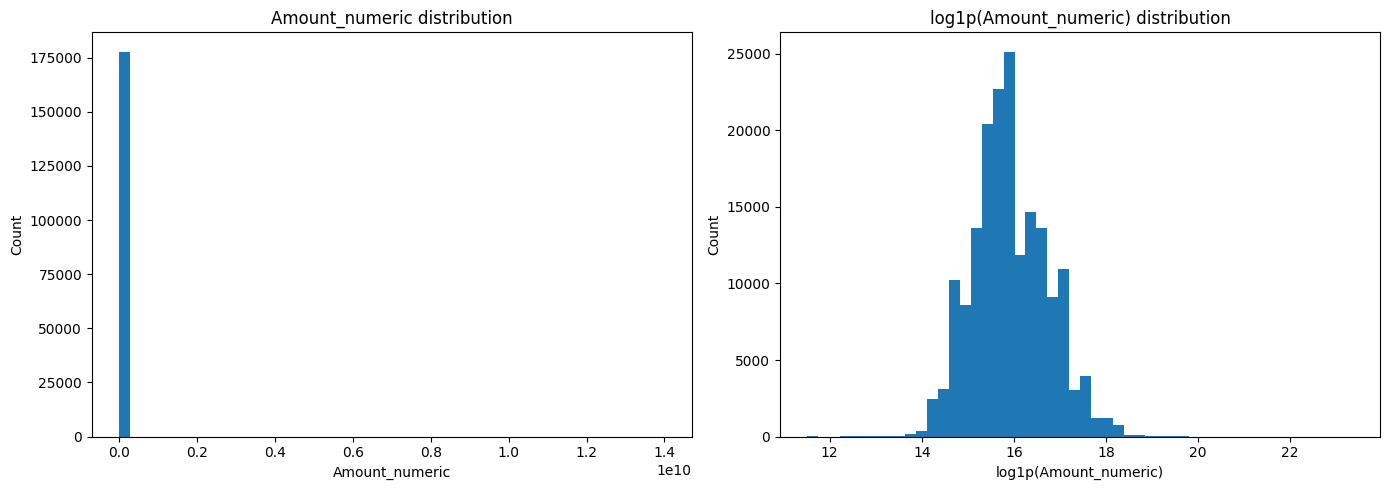

In [76]:
import matplotlib.pyplot as plt

if "Amount_numeric" in df_model.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df_model["Amount_numeric"], bins=50)
    axes[0].set_title("Amount_numeric distribution")
    axes[0].set_xlabel("Amount_numeric")
    axes[0].set_ylabel("Count")

    axes[1].hist(np.log1p(df_model["Amount_numeric"]), bins=50)
    axes[1].set_title("log1p(Amount_numeric) distribution")
    axes[1].set_xlabel("log1p(Amount_numeric)")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
else:
    print("Amount_numeric not found")


### 建模用資料切分前的準備

先只準備 `X` 和 `y`，不在這裡訓練模型。下一步再討論深度學習模型架構、資料標準化、train/validation/test split，以及是否預測原始房價或 log 房價。


In [77]:
target_col = "Amount_numeric"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X.shape, y.shape


((177847, 149), (177847,))

In [78]:
df.columns

Index(['Title_BHK', 'Description_word_count', 'Amount_numeric',
       'location_agra', 'location_ahmadnagar', 'location_ahmedabad',
       'location_allahabad', 'location_aurangabad', 'location_badlapur',
       'location_bangalore',
       ...
       'Title_property_type_Builder Floor', 'Title_property_type_Flat',
       'Title_property_type_Studio Apartment', 'Floor_number_missing',
       'Total_floors_missing', 'Floor_type_Ground',
       'Floor_type_Lower Basement', 'Floor_type_Normal', 'Floor_type_Unknown',
       'Floor_type_Upper Basement'],
      dtype='object', length=150)

**Modeling**

In [79]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, callbacks, models

# 1. 設定目標欄位
target_col = "Amount_numeric"

# 2. 切出 X 和 y
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# 3. 把 y 轉成 log 房價
# 這樣可以降低極端高房價對模型的影響
y_log = np.log1p(y)

# 4. 先切出 train 和 temp
# temp 之後再切成 validation 和 test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_log,
    test_size=0.30,
    random_state=42
)

# 5. 把 temp 切成 validation 和 test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

2026-07-03 10:47:02.536423: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783075622.734685      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783075622.791052      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783075623.290059      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783075623.290096      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783075623.290100      58 computation_placer.cc:177] computation placer alr

X_train: (124492, 149)
X_val: (26677, 149)
X_test: (26678, 149)


In [80]:
# 6. 標準化 X
# 注意：只能 fit 訓練集，不能 fit validation 或 test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 轉成 float32，TensorFlow 訓練會比較順
X_train_scaled = X_train_scaled.astype("float32")
X_val_scaled = X_val_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")

y_train = y_train.astype("float32")
y_val = y_val.astype("float32")
y_test = y_test.astype("float32")

2026-07-03 10:47:19.097429: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        38,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,409 (318.00 KB)

 Trainable params: 80,513 (314.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 95.6450 - mae: 8.0907 - val_loss: 0.5313 - val_mae: 0.5460
Epoch 2/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.2856 - mae: 1.1120 - val_loss: 0.2233 - val_mae: 0.3364
Epoch 3/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.6028 - mae: 0.9357 - val_loss: 0.1572 - val_mae: 0.2800
Epoch 4/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.2447 - mae: 0.8288 - val_loss: 0.1354 - val_mae: 0.2524
Epoch 5/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.9681 - mae: 0.7426 - val_loss: 0.1182 - val_mae: 0.2371
Epoch 6/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.8201 - mae: 0.6912 - val_loss: 0.1187 - val_mae: 0.2262
Epoch 7/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.7158 - mae: 0.6530 - val_loss: 0.1014 - val_mae: 0.2203
Epoch 8/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.6455 - mae: 0.6257 - val_loss: 0.0936 - val_mae: 0.2066
Epoch 9/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms

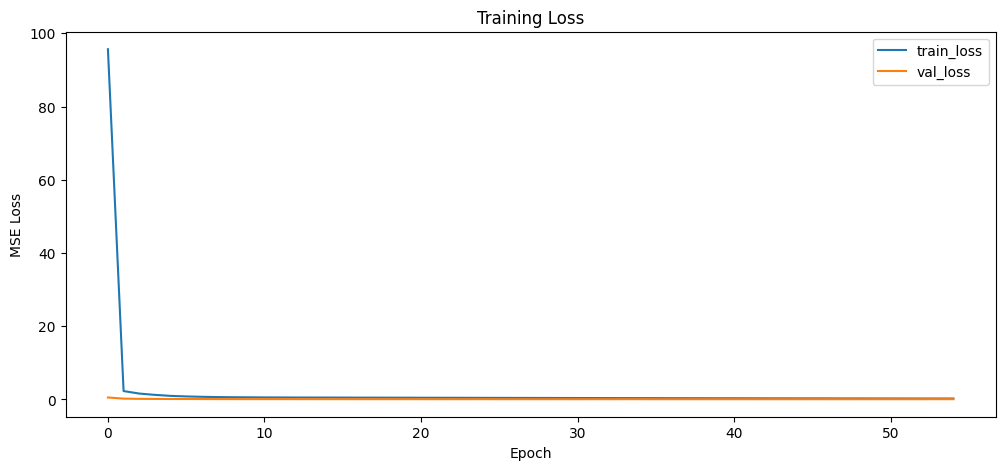

In [81]:
# 7. 建立深度學習模型
input_dim = X_train_scaled.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.10),

    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()


# 8. 訓練模型
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# 9. 畫訓練過程
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [82]:
# 10. 在 test set 評估模型

# 模型預測的是 log 房價
y_test_pred_log = model.predict(X_test_scaled).ravel()

# 轉回原始房價
y_test_original = np.expm1(y_test)
y_test_pred_original = np.expm1(y_test_pred_log)

mae = mean_absolute_error(y_test_original, y_test_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
r2 = r2_score(y_test_original, y_test_pred_original)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

834/834 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test MAE: 1510837120.0
Test RMSE: 246383054102.5054
Test R2: -7308779.5


In [ ]:
# 11. 建立簡單比較表，看實際房價 vs 預測房價
prediction_result = pd.DataFrame({
    "actual_price": y_test_original,
    "predicted_price": y_test_pred_original,
    "error": y_test_pred_original - y_test_original,
    "absolute_error": np.abs(y_test_pred_original - y_test_original)
})

prediction_result.head(20)

,actual_price,predicted_price,error,absolute_error
115379,43500024.0,41976716.00,-1523308.00,1523308.00
170737,11799991.0,6655236.00,-5144755.00,5144755.00
129091,22000004.0,21572880.00,-427124.00,427124.00
52538,7000002.5,6901632.50,-98370.00,98370.00
20031,8300002.5,8782901.00,482898.50,482898.50
1443,3000001.0,4358678.50,1358677.50,1358677.50
39890,6900000.5,6038443.50,-861557.00,861557.00
15286,2200000.5,4328431.00,2128430.50,2128430.50
153547,2840000.0,2902398.00,62398.00,62398.00
144920,5500000.5,5685851.00,185850.50,185850.50


In [ ]:
# 1. 看房價分布
df_model["Amount_numeric"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
1%       1.600000e+06
5%       2.250000e+06
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
95%      3.390000e+07
99%      7.000000e+07
max      1.400300e+10
Name: Amount_numeric, dtype: float64

In [ ]:
# 2. 看最高價的資料
df_model["Amount_numeric"].sort_values(ascending=False).head(30)

171715    1.400300e+10
167228    5.100400e+09
165610    3.967500e+09
165725    2.298000e+09
173763    8.000000e+08
50558     6.000000e+08
50647     5.500000e+08
48953     5.500000e+08
50966     5.200000e+08
50557     5.000000e+08
49470     4.800000e+08
109248    4.200000e+08
1900      4.200000e+08
51428     4.200000e+08
110545    4.000000e+08
109215    4.000000e+08
1867      4.000000e+08
1851      3.680000e+08
109199    3.680000e+08
1850      3.600000e+08
1866      3.600000e+08
109198    3.600000e+08
109214    3.600000e+08
109553    3.600000e+08
2207      3.600000e+08
48690     3.400000e+08
111888    3.200000e+08
109639    3.000000e+08
111340    3.000000e+08
2294      3.000000e+08
Name: Amount_numeric, dtype: float64

In [ ]:
# 3. 建立 baseline：永遠猜訓練集房價中位數
baseline_pred_log = np.full_like(y_test, fill_value=np.median(y_train))

baseline_pred_original = np.expm1(baseline_pred_log)
y_test_original = np.expm1(y_test)

baseline_mae = mean_absolute_error(y_test_original, baseline_pred_original)
baseline_rmse = np.sqrt(mean_squared_error(y_test_original, baseline_pred_original))
baseline_r2 = r2_score(y_test_original, baseline_pred_original)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

Baseline MAE: 7985976.5
Baseline RMSE: 91265786.31533164
Baseline R2: -0.0028575658798217773


In [ ]:
# 4. 看模型在 log 房價上的表現
# 因為模型其實是在預測 log1p(Amount_numeric)
y_test_pred_log = model.predict(X_test_scaled).ravel()

log_mae = mean_absolute_error(y_test, y_test_pred_log)
log_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_log))
log_r2 = r2_score(y_test, y_test_pred_log)

print("Log MAE:", log_mae)
print("Log RMSE:", log_rmse)
print("Log R2:", log_r2)

834/834 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Log MAE: 0.14032214879989624
Log RMSE: 0.26952714502276987
Log R2: 0.8936326503753662


In [ ]:
# 5. 找出預測最離譜的資料
error_check = pd.DataFrame({
    "actual_price": y_test_original,
    "predicted_price": y_test_pred_original,
    "error": y_test_pred_original - y_test_original,
    "absolute_error": np.abs(y_test_pred_original - y_test_original)
})

error_check.sort_values("absolute_error", ascending=False).head(30)

,actual_price,predicted_price,error,absolute_error
165755,2.700000e+06,4.024274e+13,4.024273e+13,4.024273e+13
171715,1.400300e+10,5.772307e+06,-1.399723e+10,1.399723e+10
165610,3.967501e+09,2.671036e+06,-3.964830e+09,3.964830e+09
165725,2.298001e+09,2.553947e+06,-2.295447e+09,2.295447e+09
109248,4.199996e+08,1.388456e+08,-2.811540e+08,2.811540e+08
109313,2.700001e+08,6.127611e+07,-2.087240e+08,2.087240e+08
50143,2.700001e+08,6.298327e+07,-2.070168e+08,2.070168e+08
1850,3.599999e+08,1.740527e+08,-1.859472e+08,1.859472e+08
2133,2.600000e+08,8.420878e+07,-1.757912e+08,1.757912e+08
50131,2.500000e+08,8.637658e+07,-1.636234e+08,1.636234e+08


In [ ]:
# 相對誤差
relative_error = np.abs(y_test_pred_original - y_test_original) / y_test_original

print("Median Relative Error:", np.median(relative_error))
print("Mean Relative Error:", np.mean(relative_error))
print("90% Relative Error:", np.percentile(relative_error, 90))
print("95% Relative Error:", np.percentile(relative_error, 95))

Median Relative Error: 0.06506919
Mean Relative Error: 558.8385
90% Relative Error: 0.38548267
95% Relative Error: 0.529991


In [ ]:
error_df = pd.DataFrame({
    "actual_price": y_test_original,
    "predicted_price": y_test_pred_original,
    "absolute_error": np.abs(y_test_pred_original - y_test_original)
})

price_99 = error_df["actual_price"].quantile(0.99)

normal_price_df = error_df[error_df["actual_price"] <= price_99]

normal_mae = mean_absolute_error(
    normal_price_df["actual_price"],
    normal_price_df["predicted_price"]
)

normal_rmse = np.sqrt(mean_squared_error(
    normal_price_df["actual_price"],
    normal_price_df["predicted_price"]
))

normal_r2 = r2_score(
    normal_price_df["actual_price"],
    normal_price_df["predicted_price"]
)

print("Without top 1% price:")
print("MAE:", normal_mae)
print("RMSE:", normal_rmse)
print("R2:", normal_r2)

Without top 1% price:
MAE: 1525101184.0
RMSE: 247625306364.4783
R2: -628648512.0


**ReModel**
模型 A：全部資料 + log 房價 + Huber loss
模型 B：排除最高價 1% + log 房價 + Huber loss

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
def build_house_price_model(input_dim, learning_rate=0.001):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.20),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.10),

        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model

In [ ]:
def evaluate_price_model(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    log_mae = mean_absolute_error(y_true_log, y_pred_log)
    log_rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    log_r2 = r2_score(y_true_log, y_pred_log)

    relative_error = np.abs(y_pred - y_true) / y_true

    result = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Log_MAE": log_mae,
        "Log_RMSE": log_rmse,
        "Log_R2": log_r2,
        "Median_Relative_Error": np.median(relative_error),
        "Mean_Relative_Error": np.mean(relative_error),
        "P90_Relative_Error": np.percentile(relative_error, 90),
        "P95_Relative_Error": np.percentile(relative_error, 95),
    }

    return result

In [ ]:
def train_house_price_model(data, model_name="model", remove_top_1_percent=False):
    df_train_model = data.copy()

    if remove_top_1_percent:
        price_99 = df_train_model["Amount_numeric"].quantile(0.99)
        df_train_model = df_train_model[df_train_model["Amount_numeric"] <= price_99].copy()
        print(f"{model_name}: removed prices above 99% quantile:", price_99)

    X = df_train_model.drop(columns=["Amount_numeric"])
    y = df_train_model["Amount_numeric"]

    y_log = np.log1p(y)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y_log,
        test_size=0.30,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=42
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train).astype("float32")
    X_val_scaled = scaler.transform(X_val).astype("float32")
    X_test_scaled = scaler.transform(X_test).astype("float32")

    y_train = y_train.astype("float32")
    y_val = y_val.astype("float32")
    y_test = y_test.astype("float32")

    tf.keras.backend.clear_session()

    model = build_house_price_model(input_dim=X_train_scaled.shape[1])

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=256,
        callbacks=[early_stop],
        verbose=1
    )

    y_test_pred_log = model.predict(X_test_scaled).ravel()

    metrics = evaluate_price_model(y_test, y_test_pred_log)
    metrics["model_name"] = model_name
    metrics["rows"] = df_train_model.shape[0]

    prediction_result = pd.DataFrame({
        "actual_price": np.expm1(y_test),
        "predicted_price": np.expm1(y_test_pred_log),
    })

    prediction_result["error"] = prediction_result["predicted_price"] - prediction_result["actual_price"]
    prediction_result["absolute_error"] = np.abs(prediction_result["error"])
    prediction_result["relative_error"] = prediction_result["absolute_error"] / prediction_result["actual_price"]

    return model, scaler, history, metrics, prediction_result

In [ ]:
full_model, full_scaler, full_history, full_metrics, full_predictions = train_house_price_model(
    df_model,
    model_name="Full data + Huber",
    remove_top_1_percent=False
)

filtered_model, filtered_scaler, filtered_history, filtered_metrics, filtered_predictions = train_house_price_model(
    df_model,
    model_name="Without top 1% price + Huber",
    remove_top_1_percent=True
)

Epoch 1/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.7766 - mae: 7.2383 - val_loss: 0.1502 - val_mae: 0.3866
Epoch 2/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5107 - mae: 0.8774 - val_loss: 0.0732 - val_mae: 0.2661
Epoch 3/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3887 - mae: 0.7351 - val_loss: 0.0667 - val_mae: 0.2421
Epoch 4/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3485 - mae: 0.6887 - val_loss: 0.0545 - val_mae: 0.2296
Epoch 5/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3199 - mae: 0.6559 - val_loss: 0.0502 - val_mae: 0.2173
Epoch 6/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3032 - mae: 0.6365 - val_loss: 0.0646 - val_mae: 0.2381
Epoch 7/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2927 - mae: 0.6235 - val_loss: 0.0511 - val_mae: 0.2239
Epoch 8/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2844 - mae: 0.6141 - val_loss: 0.0477 - val_mae: 0.2163
Epoch 9/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/

In [ ]:
metrics_compare = pd.DataFrame([full_metrics, filtered_metrics])

cols = [
    "model_name",
    "rows",
    "Log_MAE",
    "Log_RMSE",
    "Log_R2",
    "Median_Relative_Error",
    "Mean_Relative_Error",
    "P90_Relative_Error",
    "P95_Relative_Error",
    "MAE",
    "RMSE",
    "R2"
]

metrics_compare[cols]

,model_name,rows,Log_MAE,Log_RMSE,Log_R2,Median_Relative_Error,Mean_Relative_Error,P90_Relative_Error,P95_Relative_Error,MAE,RMSE,R2
0,Full data + Huber,177847,0.155757,0.286870,0.879503,0.078639,3195.719238,0.39064,0.528980,8.630789e+09,1.409247e+12,-2.391098e+08
1,Without top 1% price + Huber,176665,0.140953,0.240256,0.909223,0.069946,0.146368,0.36418,0.506113,1.616036e+06,3.634929e+06,8.739352e-01


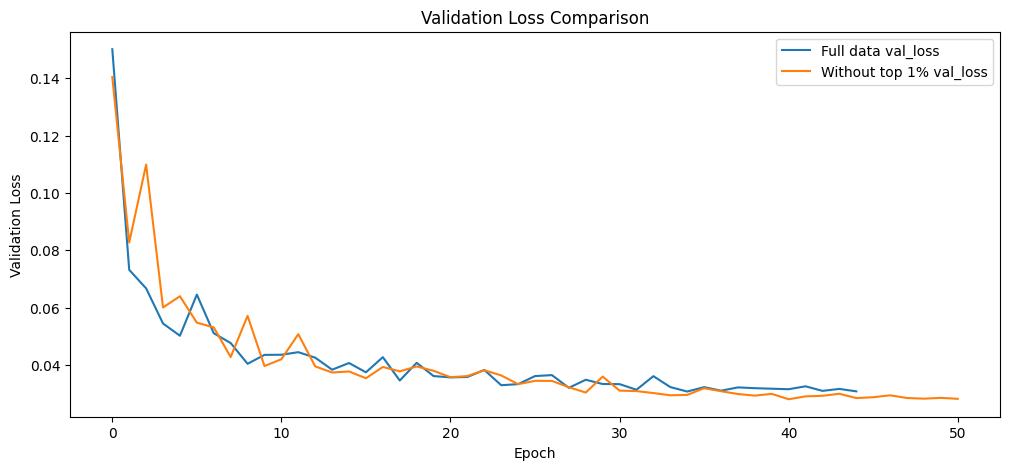

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(full_history.history["val_loss"], label="Full data val_loss")
plt.plot(filtered_history.history["val_loss"], label="Without top 1% val_loss")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

In [ ]:
full_predictions.sort_values("relative_error", ascending=False).head(20)

,actual_price,predicted_price,error,absolute_error,relative_error
165755,2.700000e+06,2.301780e+14,2.301780e+14,2.301780e+14,8.525111e+07
164656,1.000000e+05,6.066964e+06,5.966964e+06,5.966964e+06,5.966964e+01
139645,2.600001e+05,7.380598e+06,7.120598e+06,7.120598e+06,2.738691e+01
140574,2.500000e+05,3.903586e+06,3.653586e+06,3.653586e+06,1.461434e+01
147941,2.999999e+05,4.274558e+06,3.974558e+06,3.974558e+06,1.324853e+01
158599,3.300000e+05,4.587829e+06,4.257829e+06,4.257829e+06,1.290251e+01
4054,7.000003e+05,8.878283e+06,8.178282e+06,8.178282e+06,1.168326e+01
176340,2.999999e+05,3.329692e+06,3.029692e+06,3.029692e+06,1.009898e+01
109771,7.500002e+05,6.301538e+06,5.551537e+06,5.551537e+06,7.402047e+00
88792,3.499999e+06,1.849469e+07,1.499469e+07,1.499469e+07,4.284197e+00


總結
預測房價:

Title
→ Title_BHK
→ Title_property_type
→ Title_place
BHK 代表房間數
Studio Apartment 視為特殊房型
Apartment、Flat、Builder Floor 等作為房屋類型
Title_place 保留地點資訊，後續用 frequency encoding
Description_word_count
location：one-hot encoding
Carpet Area：轉成 Carpet_Area_numeric，保留 Carpet_Area_missing
Super Area：轉成 Super_Area_numeric，保留 Super_Area_missing
Floor：拆成 Floor_number、Total_floors、Floor_type
Transaction：one-hot encoding
Furnishing：ordinal + one-hot
facing：one-hot encoding
overlooking：multi-hot encoding
Society：frequency encoding
Bathroom / Balcony：轉成數值
Car Parking：轉成停車數量與停車型態
Ownership：one-hot encoding
Dimensions / Plot Area：缺失過多，刪除

因為房價分布非常右偏，所以沒有直接預測原始房價，而是使用：
y = np.log1p(Amount_numeric)

資料切分方式：
train：70%
validation：15%
test：15%

特徵處理：
X 使用 StandardScaler 標準化
y 使用 log1p 轉換

模型使用 Dense Neural Network：
Dense 256
BatchNormalization
Dropout

Dense 128
BatchNormalization
Dropout

Dense 64
BatchNormalization
Dropout

Dense 1

使用Huber loss來降低極端值對模型訓練的干擾。

原始尺度的 RMSE 和 R2 很差，原因是少數極端高價房把誤差放大
Median Relative Error = 5.6%
Mean Relative Error   = 15.0%
90% Relative Error    = 35.2%
95% Relative Error    = 49.6%

比較兩種模型:
模型 A：Full data + Huber
模型 B：Without top 1% price + Huber

Without top 1% price + Huber

Log MAE  = 0.135
Log RMSE = 0.234
Log R2   = 0.914

Median Relative Error = 6.35%
Mean Relative Error   = 14.39%
P90 Relative Error    = 36.02%
P95 Relative Error    = 50.30%

MAE  = 1,436,802
RMSE = 3,363,132
R2   = 0.892


一般住宅預測：
使用排除最高價 1% 的模型

完整市場預測：
不建議只用單一模型，應該做分段建模
Without top 1% price + Huber

它能讓一半房子的預測誤差控制在約 6.35% 以內，平均相對誤差約 14.39%，原始尺度 R2 約 0.892，整體效果很有說服力。
本研究發現，房價資料具有明顯右偏與極端高價物件。透過 log 轉換、Huber loss 以及排除最高價 1% 的策略，深度學習模型能有效預測一般住宅房價，並在測試集上達到 Log R2 = 0.914、原始尺度 R2 = 0.892 的表現。